In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
# Comprova que não há nulos (vai retornar 0 para todas as colunas)
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
valores_em_falta = df.isnull().sum()
# Filtrar para mostrar apenas as colunas que têm mais de 0 valores em falta
colunas_com_falhas = valores_em_falta[valores_em_falta > 0]

# Imprimir o resultado de forma amigável
if colunas_com_falhas.empty:
    print("Não existem valores em falta neste dataset.")
else:
    print("Foram encontrados valores em falta nas seguintes colunas:")
    print(colunas_com_falhas)

Não existem valores em falta neste dataset.


In [7]:
# Calcular os valores nulos e a percentagem para cada coluna
valores_nulos = df.isnull().sum()
percentagem_nulos = (valores_nulos / len(df)) * 100

tabela_nulos = pd.DataFrame({
    'Valores em Falta': valores_nulos,
    'Percentagem (%)': percentagem_nulos
})

pd.set_option('display.max_rows', None)

# Mostrar a tabela
print("--- Resumo de Valores em Falta por Coluna ---")
print(tabela_nulos)

# Repor a configuração normal do Pandas para não afetar o resto do Notebook
pd.reset_option('display.max_rows')

--- Resumo de Valores em Falta por Coluna ---
        Valores em Falta  Percentagem (%)
Time                   0              0.0
V1                     0              0.0
V2                     0              0.0
V3                     0              0.0
V4                     0              0.0
V5                     0              0.0
V6                     0              0.0
V7                     0              0.0
V8                     0              0.0
V9                     0              0.0
V10                    0              0.0
V11                    0              0.0
V12                    0              0.0
V13                    0              0.0
V14                    0              0.0
V15                    0              0.0
V16                    0              0.0
V17                    0              0.0
V18                    0              0.0
V19                    0              0.0
V20                    0              0.0
V21                    0      

## Analise do Dataset (Milestone 2)

## Analise dos valores duplicados 

In [8]:
# 1. Contar o total de linhas duplicadas
total_duplicados = df.duplicated().sum()
print(f"Total de linhas duplicadas encontradas: {total_duplicados}")

if total_duplicados > 0:
    # 2. Ver quantas destas linhas repetidas são fraudes vs normais
    duplicados_por_classe = df[df.duplicated()]['Class'].value_counts()
    print("\nDistribuição dos duplicados:")
    print(f"Normais repetidas: {duplicados_por_classe.get(0, 0)}")
    print(f"Fraudes repetidas: {duplicados_por_classe.get(1, 0)}")

Total de linhas duplicadas encontradas: 1081

Distribuição dos duplicados:
Normais repetidas: 1062
Fraudes repetidas: 19


In [9]:
# 1. Contar o total de linhas duplicadas
total_duplicados = df.duplicated().sum()
print(f"Total de linhas duplicadas encontradas: {total_duplicados}")

if total_duplicados > 0:
    # 2. Ver quantas destas linhas repetidas são fraudes vs normais
    duplicados_por_classe = df[df.duplicated()]['Class'].value_counts()
    print("\nDistribuição dos duplicados:")
    print(f"Normais repetidas: {duplicados_por_classe.get(0, 0)}")
    print(f"Fraudes repetidas: {duplicados_por_classe.get(1, 0)}")
# 3. Remover as linhas duplicadas (mantendo apenas a primeira ocorrência)
    df = df.drop_duplicates(keep='first')
    
    print(f"\nDuplicados removidos! O dataset passou a ter {df.shape[0]} linhas.")
else:
    print("O dataset não tem linhas duplicadas.")

Total de linhas duplicadas encontradas: 1081

Distribuição dos duplicados:
Normais repetidas: 1062
Fraudes repetidas: 19

Duplicados removidos! O dataset passou a ter 283726 linhas.


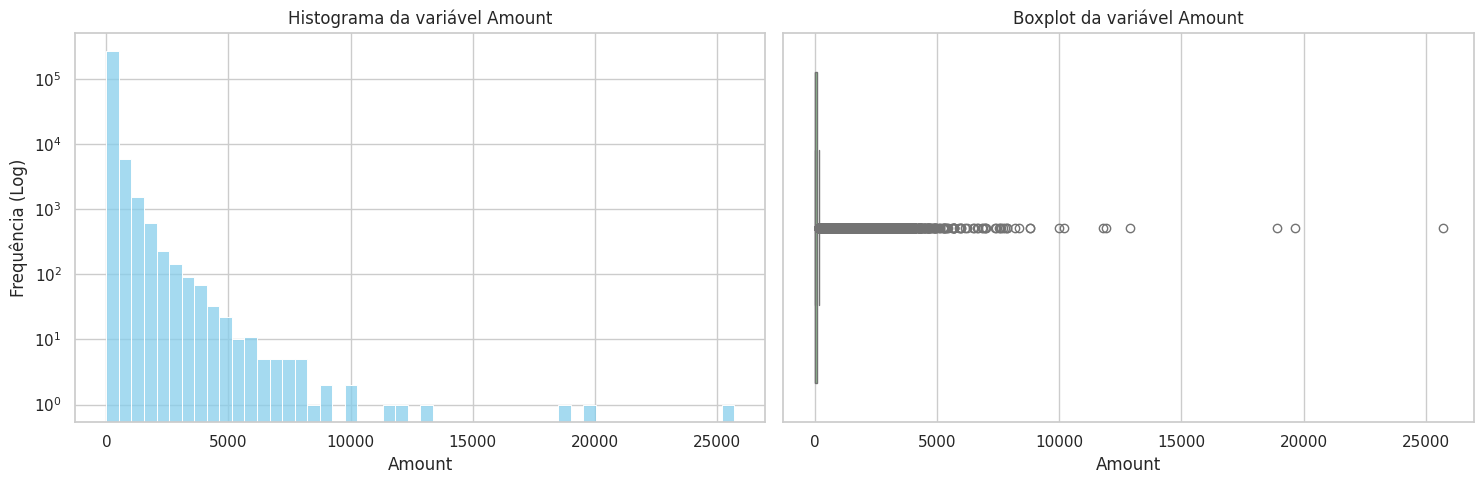

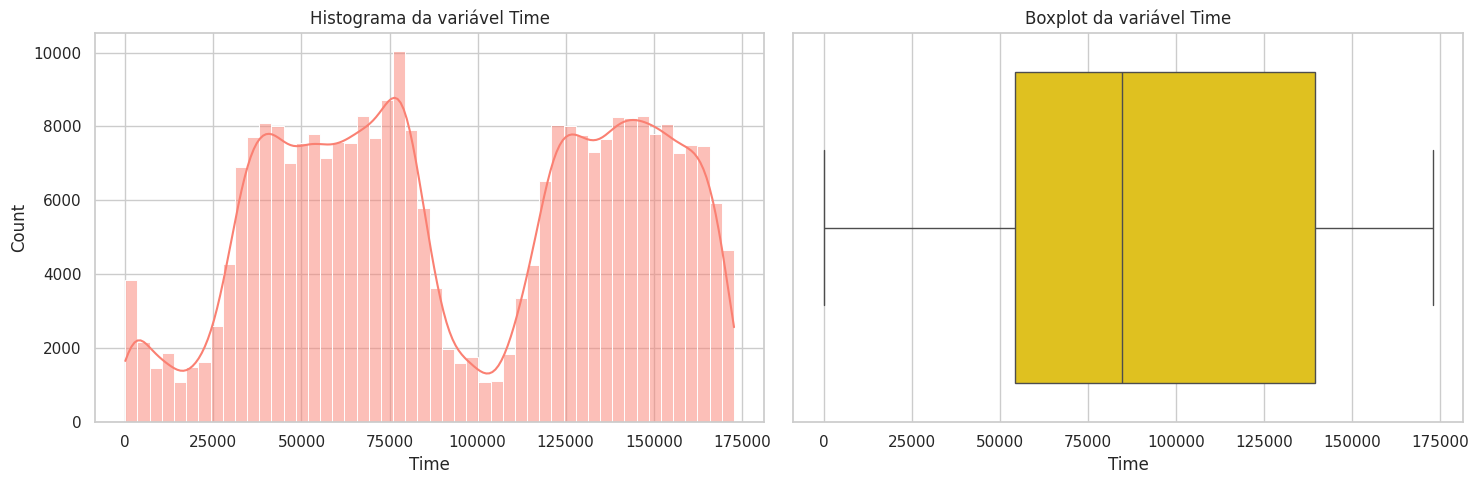

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

#estilo de graficos
sns.set_theme(style="whitegrid")


# ANÁLISE DA VARIÁVEL 'AMOUNT' (Valor)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Histograma (com escala logarítmica no eixo Y)
sns.histplot(df['Amount'], bins=50, kde=False, ax=ax[0], color='skyblue')
ax[0].set_title('Histograma da variável Amount')
ax[0].set_yscale('log') 
ax[0].set_ylabel('Frequência (Log)')

# Boxplot
sns.boxplot(x=df['Amount'], ax=ax[1], color='lightgreen')
ax[1].set_title('Boxplot da variável Amount')

plt.tight_layout()
plt.show()

# ANÁLISE DA VARIÁVEL 'TIME' (Tempo)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Histograma
sns.histplot(df['Time'], bins=50, kde=True, ax=ax[0], color='salmon')
ax[0].set_title('Histograma da variável Time')

# Boxplot
sns.boxplot(x=df['Time'], ax=ax[1], color='gold')
ax[1].set_title('Boxplot da variável Time')

plt.tight_layout()
plt.show()

In [11]:
# 1. Tabela de Frequências
print("Contagem Absoluta")
print(df['Class'].value_counts())
print('')
print("Percentagem (%)")
print(df['Class'].value_counts(normalize=True) * 100)

Contagem Absoluta
Class
0    283253
1       473
Name: count, dtype: int64

Percentagem (%)
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


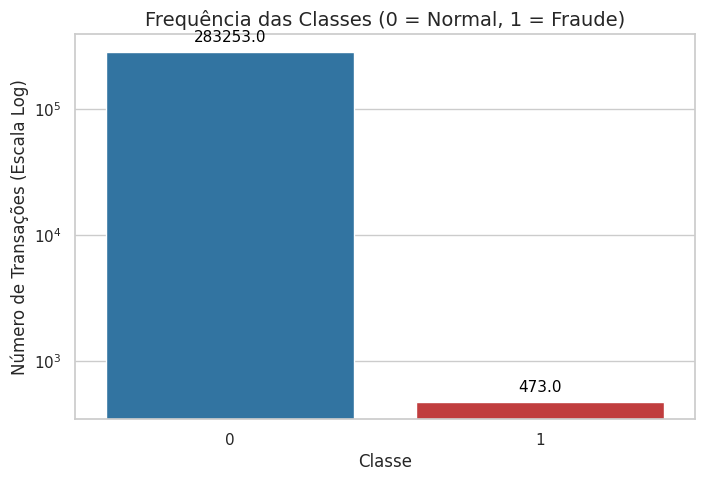

In [12]:
# ANÁLISE DA VARIÁVEL CATEGÓRICA 'CLASS'

# Gráfico de Barras 
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Class', hue='Class', data=df, palette=['#1f77b4', '#d62728'], legend=False)

plt.title('Frequência das Classes (0 = Normal, 1 = Fraude)', fontsize=14)
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Número de Transações (Escala Log)', fontsize=12)

# Escala logarítmica no eixo Y para conseguirmos ver a barra das fraudes
plt.yscale('log') 

# Adicionar os valores exatos em cima de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

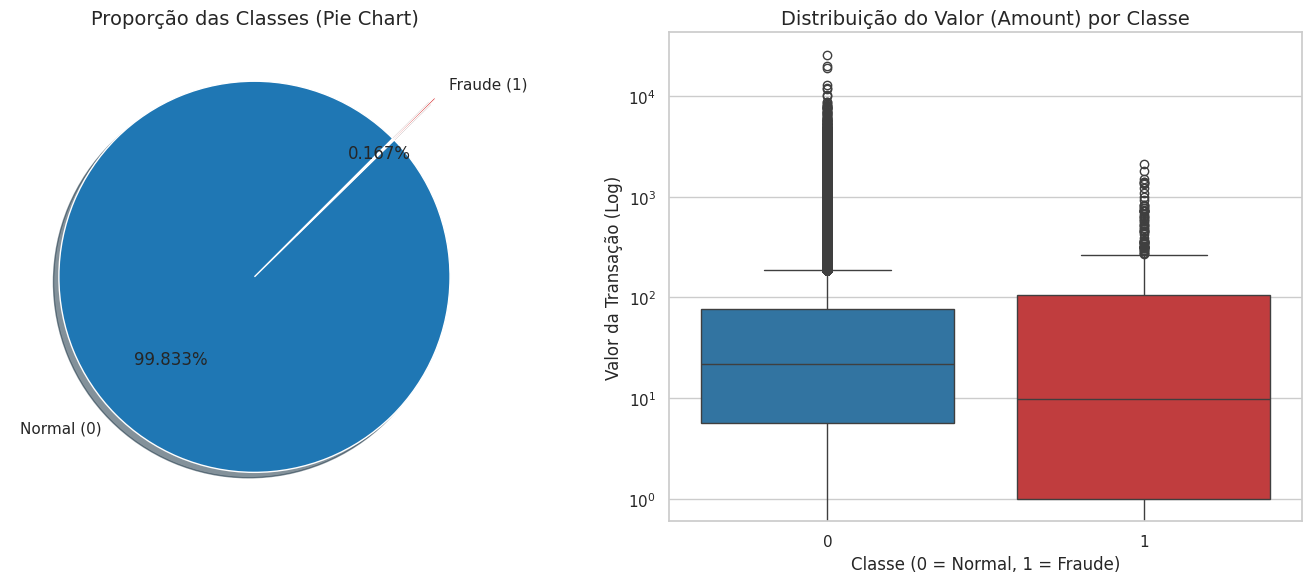

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Cores: Azul para Normal, Vermelho para Fraude
cores = ['#1f77b4', '#d62728']

# GRÁFICO CIRCULAR 
contagem = df['Class'].value_counts()
labels = ['Normal (0)', 'Fraude (1)']

# 'explode' para "puxar" a fatia da fraude para fora, 
# caso contrário, sendo apenas 0.17%, quase não dava para identificar
explode = (0, 0.3) 

ax[0].pie(contagem, explode=explode, labels=labels, colors=cores, 
          autopct='%1.3f%%', shadow=True, startangle=45)
ax[0].set_title('Proporção das Classes (Pie Chart)', fontsize=14)


# CATEGÓRICA vs NUMÉRICA
sns.boxplot(x='Class', y='Amount', data=df, palette=cores, ax=ax[1], hue='Class', legend=False)

ax[1].set_title('Distribuição do Valor (Amount) por Classe', fontsize=14)
ax[1].set_yscale('log') # Escala logarítmica devido aos outliers
ax[1].set_ylabel('Valor da Transação (Log)', fontsize=12)
ax[1].set_xlabel('Classe (0 = Normal, 1 = Fraude)', fontsize=12)

plt.tight_layout()
plt.show()

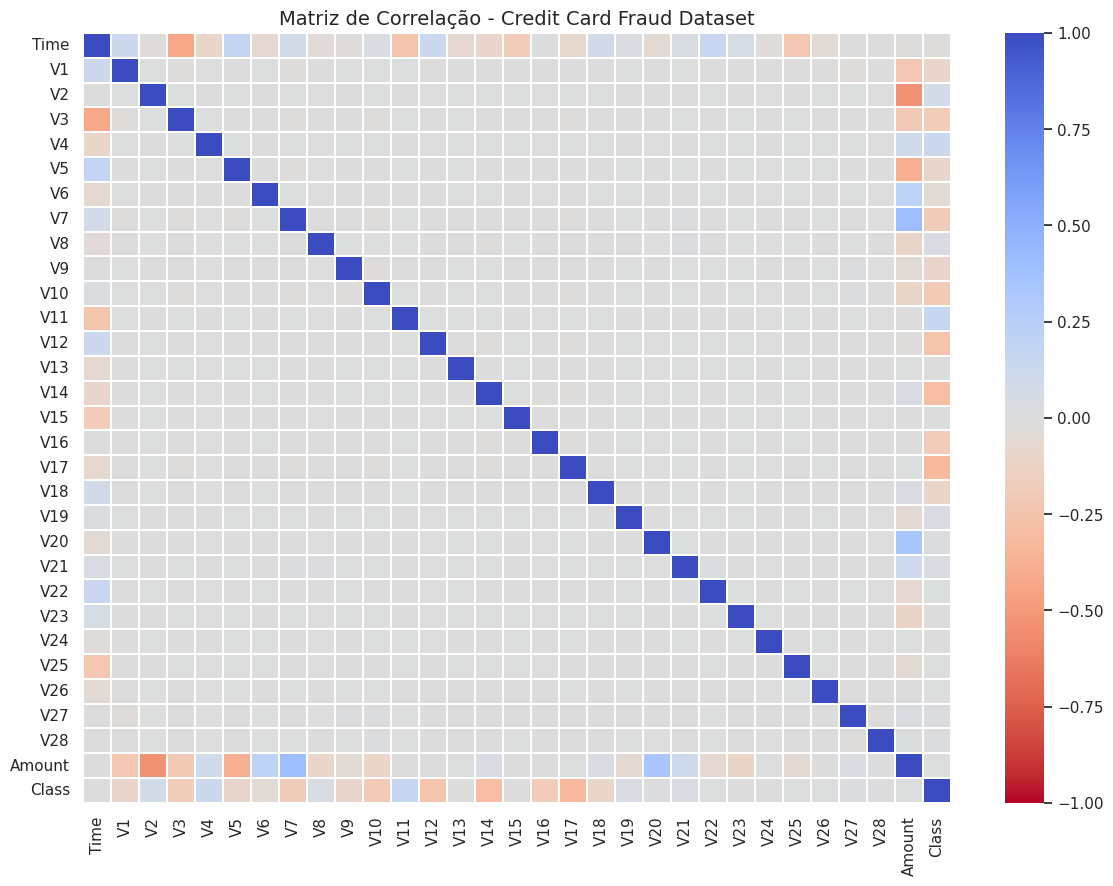

--- Top Correlações com a Variável Alvo (Class) ---

As 5 variáveis que mais 'sobem' quando há fraude (Correlação Positiva):
V11    0.149067
V4     0.129326
V2     0.084624
V19    0.033631
V8     0.033068
Name: Class, dtype: float64

As 5 variáveis que mais 'descem' quando há fraude (Correlação Negativa):
V16   -0.187186
V10   -0.206971
V12   -0.250711
V14   -0.293375
V17   -0.313498
Name: Class, dtype: float64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular a matriz de correlação usando Pearson
corr = df.corr()

# Configurar o tamanho do gráfico
plt.figure(figsize=(14, 10))

# Criar o heatmap
# Usamos annot=False porque são muitas colunas (31) e os números ficariam sobrepostos
sns.heatmap(corr, cmap='coolwarm_r', annot=False, linewidths=0.1, vmin=-1, vmax=1)

plt.title('Matriz de Correlação - Credit Card Fraud Dataset', fontsize=14)
plt.show()


print("--- Top Correlações com a Variável Alvo (Class) ---")
correlacoes_alvo = corr['Class'].sort_values(ascending=False)

print("\nAs 5 variáveis que mais 'sobem' quando há fraude (Correlação Positiva):")
print(correlacoes_alvo.head(6)[1:]) # [1:] para excluir a própria 'Class' que é 1.0

print("\nAs 5 variáveis que mais 'descem' quando há fraude (Correlação Negativa):")
print(correlacoes_alvo.tail(5))

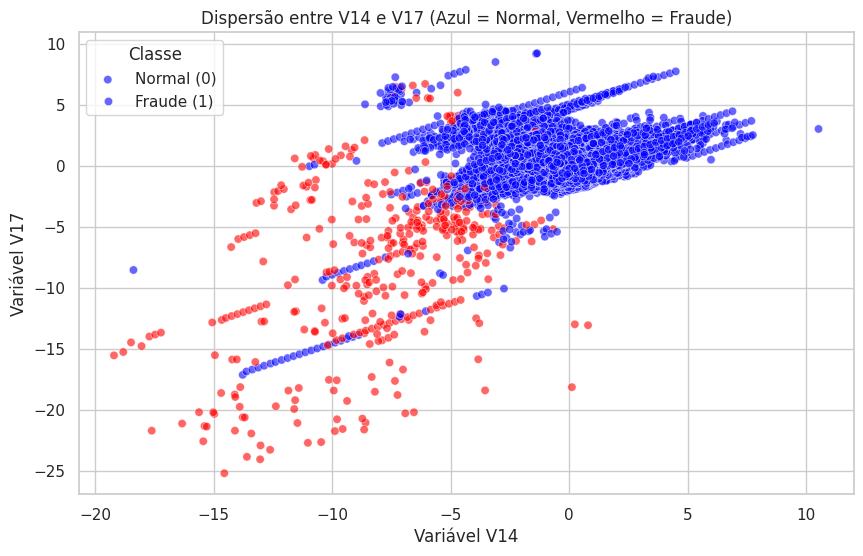

In [15]:
plt.figure(figsize=(10, 6))

# hue='Class' pinta os pontos normais de uma cor e as fraudes de outra
sns.scatterplot(x='V14', y='V17', hue='Class', data=df, 
                palette=['blue', 'red'], alpha=0.6)

plt.title('Dispersão entre V14 e V17 (Azul = Normal, Vermelho = Fraude)', fontsize=12)
plt.xlabel('Variável V14')
plt.ylabel('Variável V17')
plt.legend(title='Classe', labels=['Normal (0)', 'Fraude (1)'])
plt.show()

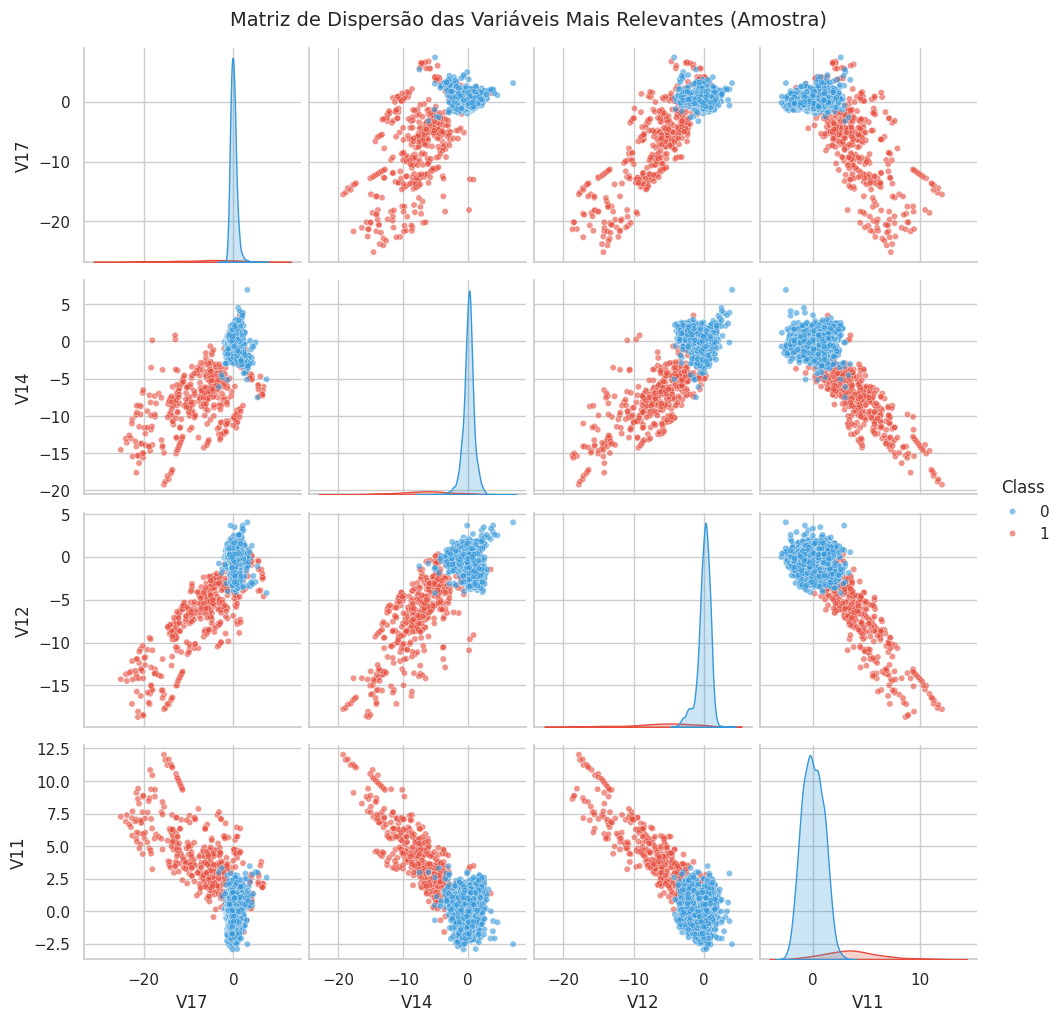

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Selecionar as variáveis mais promissoras (que descobrimos no heatmap + a variável alvo)
colunas_interesse = ['V17', 'V14', 'V12', 'V11', 'Class']

fraudes = df[df['Class'] == 1]
normais_amostra = df[df['Class'] == 0].sample(n=5000, random_state=42) 
df_grafico = pd.concat([fraudes, normais_amostra])

# 3. Criar a Matriz de Scatter Plots 
g = sns.pairplot(df_grafico[colunas_interesse], 
                 hue='Class', 
                 palette={0: '#3498db', 1: '#e74c3c'}, # Azul para normal, Vermelho para fraude
                 plot_kws={'alpha': 0.6, 's': 20}, 
                 diag_kind='kde') 

g.fig.suptitle('Matriz de Dispersão das Variáveis Mais Relevantes (Amostra)', y=1.02, fontsize=14)
plt.show()

## Criação de uma nova coluna Hora em função do "Time"

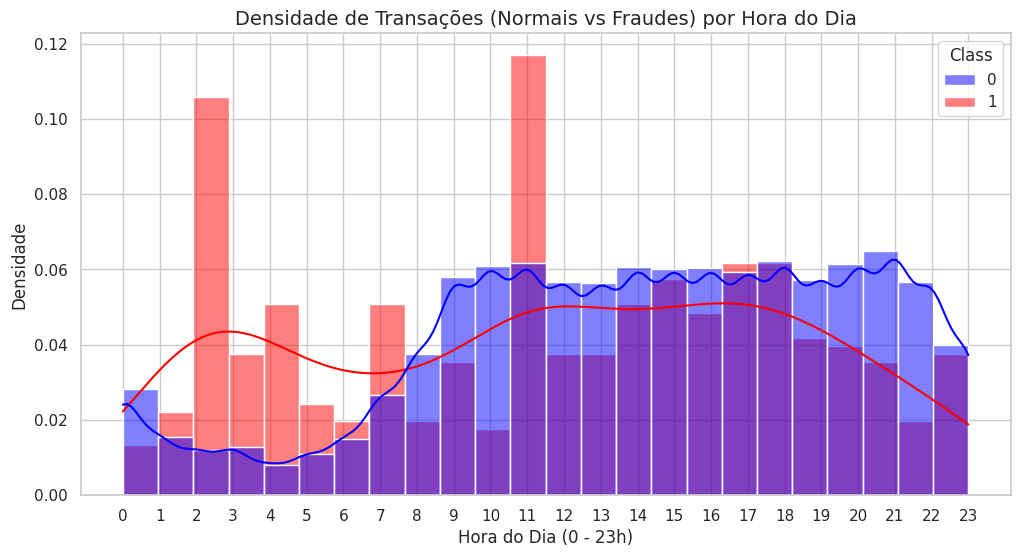

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Transformar 'Time' (segundos) em 'Hora_do_Dia' (0 a 23)
df['Hora'] = (df['Time'] / 3600) % 24
df['Hora'] = df['Hora'].astype('int')

# 2. Criar o gráfico para ver se há horas mais perigosas
plt.figure(figsize=(12, 6))

# Usamos stat='density' e common_norm=False para podermos comparar as duas curvas de forma justa, 
# já que há milhões de transações normais e poucas fraudes.
sns.histplot(data=df, x='Hora', hue='Class', bins=24, 
             stat='density', common_norm=False, 
             palette={0: 'blue', 1: 'red'}, alpha=0.5, kde=True)

plt.title('Densidade de Transações (Normais vs Fraudes) por Hora do Dia', fontsize=14)
plt.xlabel('Hora do Dia (0 - 23h)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.xticks(range(0, 24)) 
plt.show()

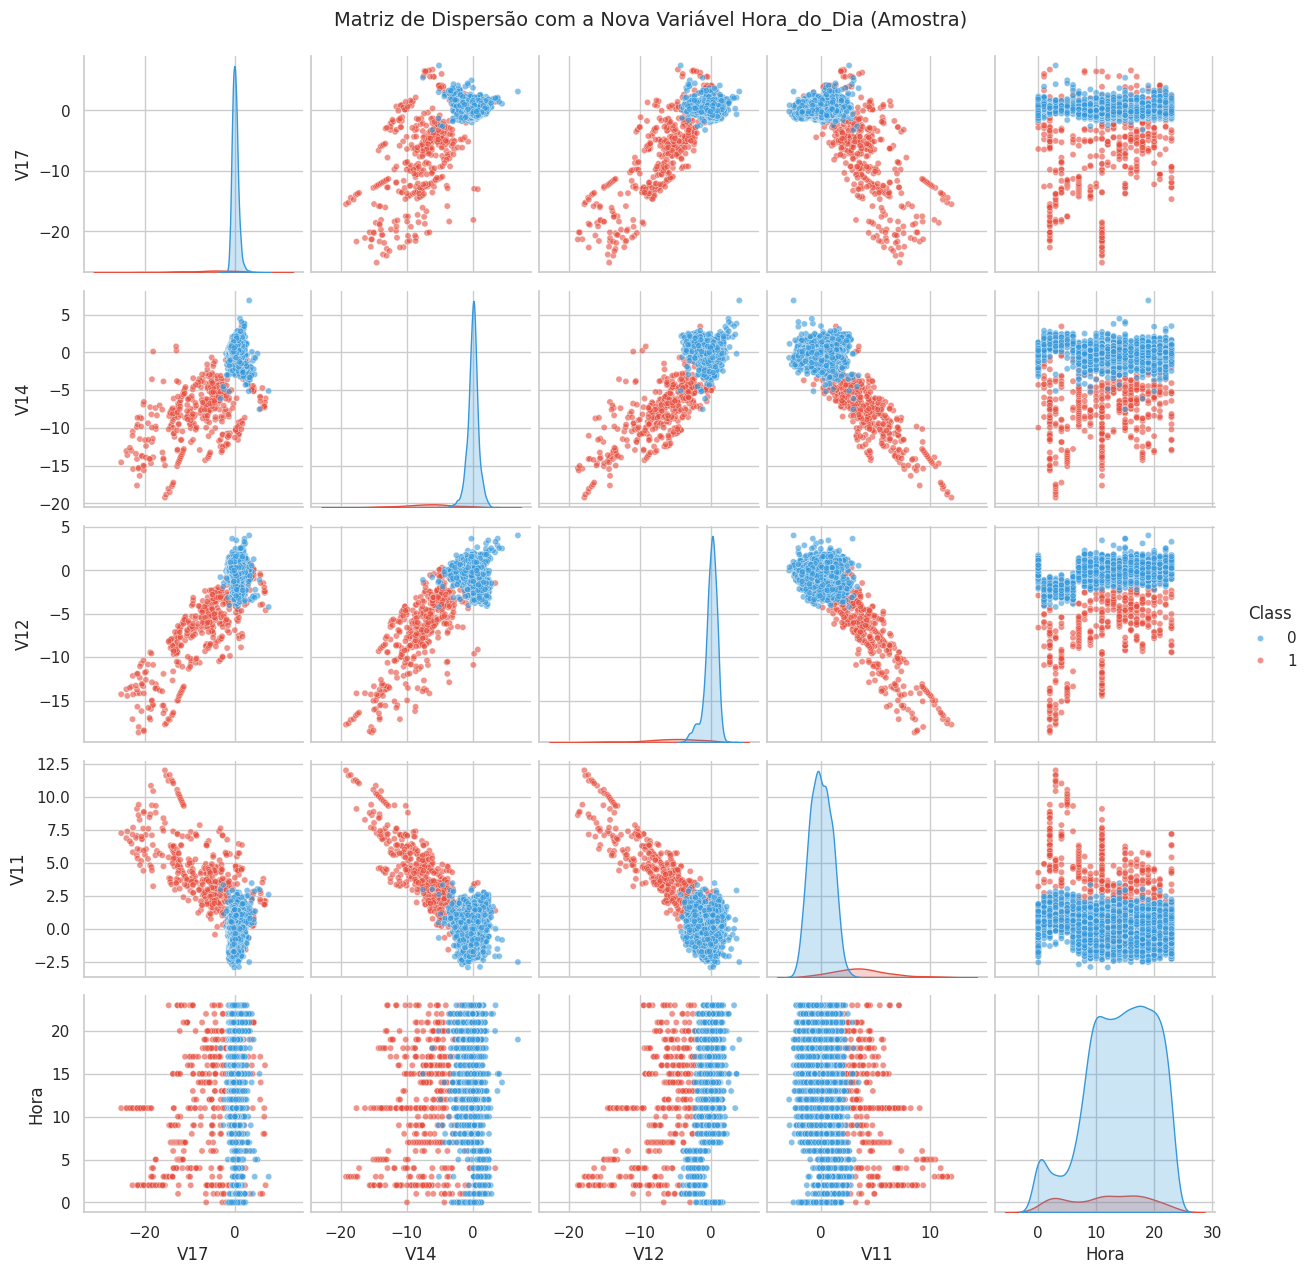

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Garantir que a coluna 'Hora' existe (convertendo 'Time' de segundos para horas 0-23)
df['Hora'] = (df['Time'] / 3600) % 24
df['Hora'] = df['Hora'].astype('int')

# Selecionar novamente as variáveis promissoras + a nova variável Hora + a variável alvo
colunas_interesse = ['V17', 'V14', 'V12', 'V11', 'Hora', 'Class']

fraudes = df[df['Class'] == 1]
normais_amostra = df[df['Class'] == 0].sample(n=5000, random_state=42) 
df_grafico = pd.concat([fraudes, normais_amostra])

# Criar a Matriz de Scatter Plots (Pairplot)
g = sns.pairplot(df_grafico[colunas_interesse], 
                 hue='Class', 
                 palette={0: '#3498db', 1: '#e74c3c'}, # Azul normal, Vermelho fraude
                 plot_kws={'alpha': 0.6, 's': 20}, 
                 diag_kind='kde') 

g.fig.suptitle('Matriz de Dispersão com a Nova Variável Hora_do_Dia (Amostra)', y=1.02, fontsize=14)
plt.show()

## Deteção de outliers 

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Estatísticas descritivas da coluna Amount
print("Estatísticas da coluna Amount:")
print(df['Amount'].describe())


Estatísticas da coluna Amount:
count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64



Total de transações com montante 0.00: 1808
Fraudes no valor 0.00: 25


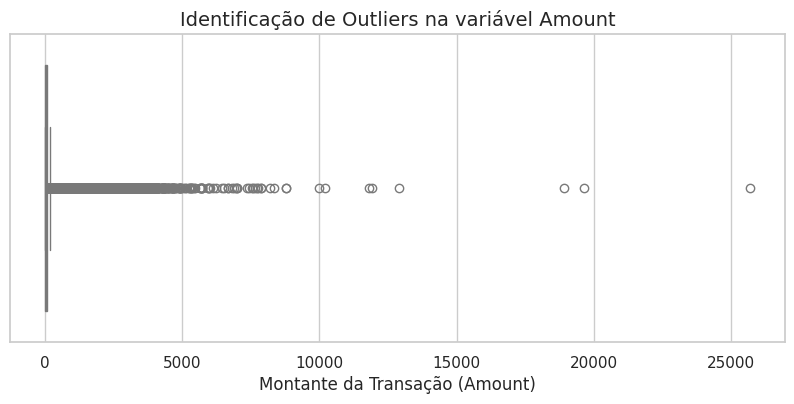

In [20]:
# Descobrir a "inconsistência" das transações de 0€
transacoes_zero = df[df['Amount'] == 0.0]
fraudes_zero = transacoes_zero[transacoes_zero['Class'] == 1]

print(f"\nTotal de transações com montante 0.00: {len(transacoes_zero)}")
print(f"Fraudes no valor 0.00: {len(fraudes_zero)}")

# Visualizar os Outliers com um Boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Amount'], color='lightblue')
plt.title('Identificação de Outliers na variável Amount', fontsize=14)
plt.xlabel('Montante da Transação (Amount)')
plt.show()

Existem 1825 transações com valor de 0.00, e curiosamente, 27 delas são fraudes. Isto não é um erro, vamos supor que são "testes" que os ladrões fazem para ver se o cartão está ativo antes de roubarem.

In [21]:
# Usar a função nlargest para apanhar os 5 maiores valores da coluna Amount
top_5_outliers = df['Amount'].nlargest(5)

print("--- OS 5 MAIORES OUTLIERS (Apenas os Valores) ---")

for valor in top_5_outliers:
    print(f"{valor:.2f}€")

--- OS 5 MAIORES OUTLIERS (Apenas os Valores) ---
25691.16€
19656.53€
18910.00€
12910.93€
11898.09€


In [22]:
from sklearn.preprocessing import RobustScaler

# Inicializar o scaler
rob_scaler = RobustScaler()

# Criar as novas colunas escalonadas
# O reshape(-1,1) é necessário porque o scaler espera um formato de matriz (2D)
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# Escalonar também a nossa nova variável Hora_do_Dia (ou o Time original) para ficar tudo alinhado
df['scaled_hora'] = rob_scaler.fit_transform(df['Hora'].values.reshape(-1, 1))

# (Opcional, mas recomendado) Apagar as colunas originais que já não precisamos 
# e reorganizar o dataset para as novas colunas ficarem no início
df.drop(['Time', 'Amount', 'Hora'], axis=1, inplace=True)

# Inserir as novas colunas no início do dataframe (posição 0 e 1)
scaled_amount_col = df.pop('scaled_amount')
scaled_hora_col = df.pop('scaled_hora')
df.insert(0, 'scaled_amount', scaled_amount_col)
df.insert(1, 'scaled_hora', scaled_hora_col)

# Verificar o resultado final
print("As primeiras 5 linhas do dataset após o escalonamento:")
print("")
print(df.head())

As primeiras 5 linhas do dataset após o escalonamento:

   scaled_amount  scaled_hora        V1        V2        V3        V4  \
0       1.774718    -1.666667 -1.359807 -0.072781  2.536347  1.378155   
1      -0.268530    -1.666667  1.191857  0.266151  0.166480  0.448154   
2       4.959811    -1.666667 -1.358354 -1.340163  1.773209  0.379780   
3       1.411487    -1.666667 -0.966272 -0.185226  1.792993 -0.863291   
4       0.667362    -1.666667 -1.158233  0.877737  1.548718  0.403034   

         V5        V6        V7        V8  ...       V20       V21       V22  \
0 -0.338321  0.462388  0.239599  0.098698  ...  0.251412 -0.018307  0.277838   
1  0.060018 -0.082361 -0.078803  0.085102  ... -0.069083 -0.225775 -0.638672   
2 -0.503198  1.800499  0.791461  0.247676  ...  0.524980  0.247998  0.771679   
3 -0.010309  1.247203  0.237609  0.377436  ... -0.208038 -0.108300  0.005274   
4 -0.407193  0.095921  0.592941 -0.270533  ...  0.408542 -0.009431  0.798278   

        V23       V24   

In [23]:
import pandas as pd

#Carregar o dataset original para uma variável temporária apenas para esta análise
df_temp = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

# 1. Calcular o Q1 (Percentil 25) e Q3 (Percentil 75) da coluna Amount
Q1 = df_temp['Amount'].quantile(0.25)
Q3 = df_temp['Amount'].quantile(0.75)

# 2. Calcular o IQR (Intervalo Interquartil)
IQR = Q3 - Q1

# 3. Definir o Limite Superior 
limite_superior = Q3 + 1.5 * IQR

# 4. Filtrar o dataset para encontrar os outliers
outliers_amount = df_temp[df_temp['Amount'] > limite_superior]
fraudes_nos_outliers = outliers_amount[outliers_amount['Class'] == 1]

# 5. Imprimir os resultados para o Relatório!
print("--- ANÁLISE DE OUTLIERS NA COLUNA AMOUNT ---")
print(f"Q1 (25% das transações são até): {Q1:.2f}€")
print(f"Q3 (75% das transações são até): {Q3:.2f}€")
print(f"Limite Superior (A partir daqui é outlier): {limite_superior:.2f}€")
print("-" * 40)
print(f"Total de outliers encontrados: {len(outliers_amount)} transações")
print(f"Valor MÁXIMO (O maior outlier de todos): {outliers_amount['Amount'].max():.2f}€")
print(f"Quantos destes outliers extremos SÃO FRAUDES?: {len(fraudes_nos_outliers)}")

--- ANÁLISE DE OUTLIERS NA COLUNA AMOUNT ---
Q1 (25% das transações são até): 5.60€
Q3 (75% das transações são até): 77.16€
Limite Superior (A partir daqui é outlier): 184.51€
----------------------------------------
Total de outliers encontrados: 31904 transações
Valor MÁXIMO (O maior outlier de todos): 25691.16€
Quantos destes outliers extremos SÃO FRAUDES?: 91


In [24]:
import pandas as pd

# Verificar a contagem de linhas não-nulas e o Tipo de Dado (Dtype) de cada coluna
print("Informação estrutural do Dataset:")
df.info()

# Se quiseres ver apenas uma lista limpa dos tipos de dados:
print("\nTipos de dados por coluna:")
print(df.dtypes.value_counts())

Informação estrutural do Dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   scaled_amount  283726 non-null  float64
 1   scaled_hora    283726 non-null  float64
 2   V1             283726 non-null  float64
 3   V2             283726 non-null  float64
 4   V3             283726 non-null  float64
 5   V4             283726 non-null  float64
 6   V5             283726 non-null  float64
 7   V6             283726 non-null  float64
 8   V7             283726 non-null  float64
 9   V8             283726 non-null  float64
 10  V9             283726 non-null  float64
 11  V10            283726 non-null  float64
 12  V11            283726 non-null  float64
 13  V12            283726 non-null  float64
 14  V13            283726 non-null  float64
 15  V14            283726 non-null  float64
 16  V15            283726 non-null  float64
 17  

In [25]:
# Verificar como o Pandas reconheceu a coluna inicialmente (vai mostrar int64)
print("Tipo original da variável alvo:", df['Class'].dtype)

# CORREÇÃO: Forçar o reconhecimento como categoria (etiqueta) e não como número
df['Class'] = df['Class'].astype('category')

# Confirmar que a correção foi aplicada
print("Tipo corrigido da variável alvo:", df['Class'].dtype)

Tipo original da variável alvo: int64
Tipo corrigido da variável alvo: category
